In [15]:
# 이미지 탐지 결과를 DataFrame으로 저장 한 후, csv 파일로 저장  -->> 요약 통계 정리
import os
import pandas as pd
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
img_dir = "./yolo_imgs"
img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print("img_paths : ", img_paths)

records = []
for path in img_paths:
    results = model(path, conf=0.25, verbose=False)[0]      # [0] : 단일 이미지 결과
    
    # 탐지된 객체의 바운딩 박스와 클래스 이름을 추출
    boxes = results.boxes
    names = results.names
    # print(names)

    # records 초기화 : 탐지된 객체가 없는 경우에도 기록을 남기기 위해 초기화
    if len(boxes) == 0:
        records.append({
            "image":os.path.basename(path),
            "object_count": 0,
            "classes":'',
            "avg_confidence": 0.0
        })
        continue
    
    # 클래스 ID 추출
    cls_id = boxes.cls.cpu().numpy().astype(int)
    # cpu() : pytorch 텐서를 CPU 메모리로 이동
    # numpy() : 텐서를 NumPy 배열로 변환
    # astype(int) : 클래스 ID를 정수형으로 변환
    print("--------------------------------")
    print("cls_id : ", cls_id)          # ex) cls_id :  [0 0 3 0 0 2]   -->> 클래스 ID가 0(person), 2(car), 3(motorcycle)인 객체 총 6개가 탐지됨

    # confidence 추출
    confs = boxes.conf.cpu().numpy()
    print("confs : ", confs)            # ex) confs :  [    0.89472     0.88528     0.84669     0.69414     0.28266     0.25905]   -->> 각 객체의 신뢰도 값

    # 클래스 이름 추출
    classes = [names[i] for i in cls_id]   # 클래스 ID를 클래스 이름으로 변환
    print("classes : ", classes)        # ex) classes :  ['person', 'person', 'motorcycle', 'person', 'person', 'car']   -->> 각 객체의 클래스 이름

    # 평균 신뢰도 계산
    avg_conf = float(confs.mean())

    # 탐지된 객체의 수, 클래스 이름, 평균 신뢰도를 records 리스트에 저장
    records.append({
        "image": os.path.basename(path),
        "object_count": len(cls_id),
        "classes": ', '.join(sorted(set(classes))), # 중복 제거 및 정렬된 클래스 이름을 문자열로 저장
        "avg_confidence": round(avg_conf, 3)
    })

img_paths :  ['./yolo_imgs/image2.jpg', './yolo_imgs/image1.jpg', './yolo_imgs/image3.jpg', './yolo_imgs/street_dog.jpg', './yolo_imgs/petimage.jpg', './yolo_imgs/street_cat.jpg', './yolo_imgs/dog.jpg']
--------------------------------
cls_id :  [ 0  0 26  0]
confs :  [    0.82473     0.72216     0.43466     0.30244]
classes :  ['person', 'person', 'handbag', 'person']
--------------------------------
cls_id :  [0 0]
confs :  [    0.81587     0.46298]
classes :  ['person', 'person']
--------------------------------
cls_id :  [0 0 3 0 0 2]
confs :  [    0.89472     0.88528     0.84669     0.69414     0.28266     0.25905]
classes :  ['person', 'person', 'motorcycle', 'person', 'person', 'car']
--------------------------------
cls_id :  [16]
confs :  [    0.92418]
classes :  ['dog']
--------------------------------
cls_id :  [16 16 16 16]
confs :  [    0.89699     0.58793     0.55349     0.27523]
classes :  ['dog', 'dog', 'dog', 'dog']
--------------------------------
cls_id :  [16 16 15]

In [18]:
# Records 리스트를 DataFrame으로 변환
df = pd.DataFrame(records)
print(df)

# DataFrame을 CSV 파일로 저장
df.to_csv("yolo6report.csv", index=False, encoding='utf-8-sig')
print("Detection summary saved to yolo6report.csv")

            image  object_count                  classes  avg_confidence
0      image2.jpg             4          handbag, person           0.571
1      image1.jpg             2                   person           0.639
2      image3.jpg             6  car, motorcycle, person           0.644
3  street_dog.jpg             1                      dog           0.924
4    petimage.jpg             4                      dog           0.578
5  street_cat.jpg             3                 cat, dog           0.689
6         dog.jpg             2                      dog           0.707
Detection summary saved to yolo6report.csv


            image  object_count                  classes  avg_confidence
0      image2.jpg             4          handbag, person           0.571
1      image1.jpg             2                   person           0.639
2      image3.jpg             6  car, motorcycle, person           0.644
3  street_dog.jpg             1                      dog           0.924
4    petimage.jpg             4                      dog           0.578
5  street_cat.jpg             3                 cat, dog           0.689
6         dog.jpg             2                      dog           0.707

총 이미지 수            : 7
총 탐지 객체 수          : 22
전체 confidence 평균    : 0.6788571428571428
클래스 별 등장 이미지 수 :
  dog: 4
  person: 3
  handbag: 1
  car: 1
  motorcycle: 1
  cat: 1
object_count 및 avg_confidence 요약 통계:
       object_count  avg_confidence
count      7.000000        7.000000
mean       3.142857        0.678857
std        1.676163        0.119442
min        1.000000        0.571000
25%        2.000000      

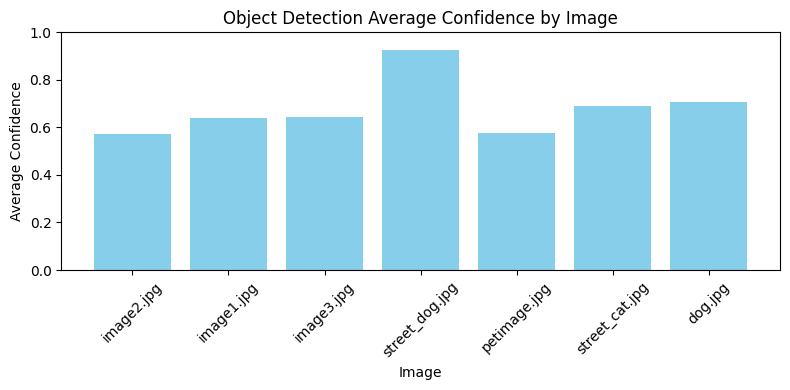

In [34]:
# csv 로딩
mydf = pd.read_csv("yolo6report.csv")
print(mydf)

# 이미지 수
num_images = len(mydf)

# 총 객체 수
total_objects = mydf['object_count'].sum()

# 평균 신뢰도 계산 (객체가 탐지된 이미지에 대해서만)
overall_avg_conf = mydf.loc[mydf['object_count'] > 0, 'avg_confidence'].mean()

# 클래스 별 등장 이미지 수
class_counts = mydf['classes'].str.split(', ').explode().value_counts()             # explode() : 리스트 형태의 문자열을 개별 행으로 분리하여 카운트

# 요약 통계 출력
print()
print(f"총 이미지 수            : {num_images}")
print(f"총 탐지 객체 수          : {total_objects}")
print(f"전체 confidence 평균    : {overall_avg_conf}")
print("클래스 별 등장 이미지 수 :")
for cls, count in class_counts.items():
    print(f"  {cls}: {count}")
print("object_count 및 avg_confidence 요약 통계:")
print(mydf[["object_count", "avg_confidence"]].describe())
print("가장 많이 탐지된 클래스 : ", class_counts.idxmax(), " (", class_counts.max(), " 이미지에서 탐지됨 )")

# 평균 신뢰도 막대 그래프 plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(mydf["image"], mydf["avg_confidence"], color='skyblue')
plt.xlabel("Image")
plt.ylabel("Average Confidence")
plt.title("Object Detection Average Confidence by Image")
plt.ylim([0, 1])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
